# [실습 14-1] 데이터 편향 시각화와 공정성 지표 계산

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | 14.2 편향과 공정성 |
| 선수 실습 | [실습 6-1] (혼동 행렬·평가지표 재사용) |
| 준비 | 부록 B.1·B.3 참고. 최초 실행 시 데이터 다운로드(수 MB) |

"공정한가?"를 느낌이 아니라 **숫자로** 따진다 —
실제 인구조사 데이터(UCI Adult)에서 집단별 격차를 시각화하고,
6장에서 배운 혼동 행렬로 공정성 지표 두 가지를 직접 계산한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/<저장소>/ai-intro-labs.git
# %cd ai-intro-labs/notebooks
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch14/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from utils import plot_style
from utils.data import fix_ssl

plot_style.apply()              # 도해 스타일 킷 적용
fix_ssl()                       # 로컬 macOS 다운로드 대비
print("Python", platform.python_version())
print("pandas", pd.__version__,
      "/ scikit-learn", sklearn.__version__)

Python 3.12.6
pandas 3.0.3 / scikit-learn 1.9.0


### [셀 1] 데이터 로드와 개요 📖

In [2]:
from sklearn.datasets import fetch_openml

# 1994년 미국 인구조사 표본 — 소득 예측용 공개 데이터
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame
df["high"] = (df["class"] == ">50K").astype(int)

print(f"표본 {len(df):,}명, 컬럼 {df.shape[1]}개")
print("민감 속성 sex:",
      df["sex"].value_counts().to_dict())
print(f"고소득(>50K) 비율: {df['high'].mean():.1%}")

표본 48,842명, 컬럼 16개
민감 속성 sex: {'Male': 32650, 'Female': 16192}
고소득(>50K) 비율: 23.9%


**핵심 포인트**
- 목표 변수는 "연 소득 5만 달러 초과 여부" — 대출·채용 심사 모델의 축소판이라 공정성 연구의 표준 데이터가 되었다.
- `sex`·`race`가 **민감 속성**(14.2)이다 — 이 컬럼으로 집단을 나눠 모델의 대우 차이를 측정한다.

기대 출력: 표본 48,842명, 고소득 비율 23.9%

### [셀 2] 학습 이전, 데이터 자체의 편향 📖

sex
Female    0.109
Male      0.304
Name: high, dtype: float64


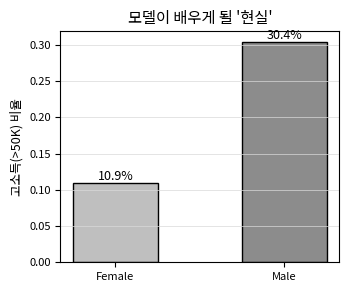

In [3]:
rate = df.groupby("sex")["high"].mean()
print(rate.round(3))

fig, ax = plt.subplots(figsize=(3.6, 3))
ax.bar(rate.index, rate.values, width=0.5,
       color=["#bfbfbf", "#8c8c8c"],
       edgecolor="black")
for i, v in enumerate(rate.values):
    ax.annotate(f"{v:.1%}", (i, v), ha="center",
                va="bottom", fontsize=9)
ax.set_ylabel("고소득(>50K) 비율")
ax.set_title("모델이 배우게 될 '현실'")
ax.grid(axis="x", visible=False)
plt.show()

**핵심 포인트**
- 아직 모델을 만들지도 않았는데 격차가 **약 3배**다 — 1994년 노동 시장의 역사적 편향이 데이터에 그대로 담겨 있다([그림 14-1] 편향 전파 경로의 "수집" 단계).
- 이 데이터로 학습한 모델은 이 격차를 **배운다** — 다음 셀에서 확인한다.

기대 출력: Female 10.9% / Male 30.4%

### [셀 3] 모델 학습과 집단별 혼동 행렬 📖

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# 주의: 특징에서 sex·race를 뺐다 — 그런데도?
FEATS = ["age", "education-num", "hours-per-week",
         "capital-gain", "capital-loss"]
X_tr, X_te, y_tr, y_te, s_tr, s_te = train_test_split(
    df[FEATS], df["high"], df["sex"],
    test_size=0.3, random_state=42, stratify=df["high"])

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()).fit(X_tr, y_tr)
pred = model.predict(X_te)
print(f"전체 정확도 {model.score(X_te, y_te):.3f}\n")

cms = {}
for g in ["Male", "Female"]:
    cms[g] = confusion_matrix(y_te[s_te == g],
                              pred[s_te == g])
    print(f"[{g}] 혼동 행렬\n{cms[g]}")

전체 정확도 0.818

[Male] 혼동 행렬
[[6483  360]
 [1799 1154]]
[Female] 혼동 행렬
[[4133  171]
 [ 341  212]]


**핵심 포인트**
- **6장에서 만든 그 표를 집단별로 두 번 만든다** — 공정성 측정의 재료는 새것이 아니라 혼동 행렬이다.
- 민감 속성(성별)을 특징에서 **제외했는데도** 격차가 남는 것을 다음 셀에서 보게 된다 — 다른 특징들이 성별을 대리(proxy)하기 때문이다(14.2의 핵심 함정).

실패 시 대처: 다운로드 지연 시 재실행(캐시로 2회차부터 빠름). 수치가 다르면 `random_state=42` 확인.

### [셀 4] 공정성 지표 2종 — 혼동 행렬에서 직접 계산 📖

In [5]:
def rates(cm):
    """혼동 행렬 → (긍정 예측률, TPR). 6장 지표 재사용."""
    tn, fp, fn, tp = cm.ravel()
    ppr = (tp + fp) / cm.sum()  # 고소득 판정을 받은 비율
    tpr = tp / (tp + fn)        # 실제 고소득자 중 인정 비율
    return ppr, tpr

print(f"{'집단':<8}{'긍정 예측률':>8}{'TPR':>8}")
for g, cm in cms.items():
    ppr, tpr = rates(cm)
    print(f"{g:<8}{ppr:>10.3f}{tpr:>8.3f}")

dp_gap = rates(cms["Male"])[0] - rates(cms["Female"])[0]
eo_gap = rates(cms["Male"])[1] - rates(cms["Female"])[1]
print(f"\n인구통계학적 동등성 차이: {dp_gap:.3f}")
print(f"균등 기회 차이:          {eo_gap:.3f}")

집단        긍정 예측률     TPR
Male         0.155   0.391
Female       0.079   0.383

인구통계학적 동등성 차이: 0.076
균등 기회 차이:          0.007


**핵심 포인트**
- **인구통계학적 동등성**: 집단마다 긍정 판정을 받는 **비율**이 같아야 한다는 기준 — 긍정 예측률의 차이로 잰다.
- **균등 기회**: 실제 자격이 있는 사람이 인정받을 확률(TPR)이 집단마다 같아야 한다는 기준 — TPR 차이로 잰다.
- 둘 다 0이면 공정, 0에서 멀수록 격차 — 본문 14.2의 숫자 예제와 같은 기호·용어다. 연습문제의 계산형 문항도 이 식을 그대로 쓴다.
- 실측 결과가 흥미롭다: 동등성 차이는 크지만(0.076) 균등 기회 차이는 거의 없다(0.007). **지표마다 재는 것이 다르므로 "공정한가?"의 답도 달라진다** — 그렇다면 동등성 쪽을 고치면 어떻게 될까? 다음 셀에서 확인한다.

### [셀 5] 두 지표는 동시에 잡히지 않는다 — Before/After 📖

In [6]:
proba = model.predict_proba(X_te)[:, 1]

def fair_at(thr):
    """집단별 임계값 딕셔너리 → 두 지표 차이."""
    res = {}
    for g in ["Male", "Female"]:
        m = (s_te == g).values
        p = (proba[m] >= thr[g]).astype(int)
        cm = confusion_matrix(y_te[m], p)
        res[g] = rates(cm)
    return (res["Male"][0] - res["Female"][0],
            res["Male"][1] - res["Female"][1])

# Before: 동일 임계값 0.5
dp0, eo0 = fair_at({"Male": 0.5, "Female": 0.5})
# After: 여성 임계값을 낮춰 동등성 차이를 0 근처로
male_ppr = rates(cms["Male"])[0]
t = np.quantile(proba[(s_te == "Female").values],
                1 - male_ppr)
dp1, eo1 = fair_at({"Male": 0.5, "Female": t})

print(f"{'':<22}동등성 차이  균등기회 차이")
print(f"Before (동일 0.5)     {dp0:>8.3f}{eo0:>10.3f}")
print(f"After  (여성 {t:.2f})   {dp1:>8.3f}{eo1:>10.3f}")

                      동등성 차이  균등기회 차이
Before (동일 0.5)        0.076     0.007
After  (여성 0.34)     -0.001    -0.150


**핵심 포인트**
- 여성 집단의 판정 임계값을 낮춰 동등성 차이를 0 근처로 맞추자 균등 기회 차이가 **반대 방향으로 벌어졌다** — "모든 공정성 지표를 동시에 만족할 수 없다"(14.2)의 수치 확인.
- 게다가 집단별로 다른 임계값을 쓰는 것 자체가 또 다른 차별 논쟁을 부른다 — 기술만으로 닫을 수 없는 질문이며, 그래서 거버넌스(14.5)가 필요하다.
- 어느 지표를 우선할지는 **맥락의 문제**다: 대출(기회의 평등)과 의료 자원 배분(필요 기반)은 답이 다르다.

### [보조 1] 인종 집단 확장과 전처리 상세

In [7]:
race_rate = df.groupby("race")["high"].agg(
    ["mean", "size"]).sort_values("mean")
print(race_rate.round(3))
# 표본이 작은 집단(수백 명)은 지표의 분산이 크다 —
# 보고 시 집단 병합·신뢰구간 병기가 실무 관행이다.
print("\n결측 현황:",
      df[["workclass", "occupation"]]
      .isna().sum().to_dict())
# 본 실습은 수치형 특징만 사용해 결측 영향이 없다.
# 범주형까지 쓰려면 원-핫 인코딩 후 동일 절차를 밟는다.

                     mean   size
race                            
Amer-Indian-Eskimo  0.117    470
Black               0.121   4685
Other               0.123    406
White               0.254  41762
Asian-Pac-Islander  0.269   1519

결측 현황: {'workclass': 2799, 'occupation': 2809}


### [보조 2] 임계값 스윕 — 두 지표의 줄다리기 곡선

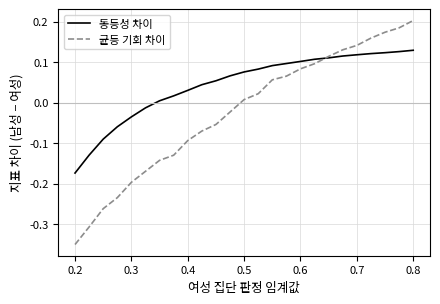

In [8]:
ts = np.linspace(0.2, 0.8, 25)
gaps = [fair_at({"Male": 0.5, "Female": t}) for t in ts]
dps, eos = zip(*gaps)

fig, ax = plt.subplots(figsize=(4.8, 3.2))
ax.plot(ts, dps, "-", color="black", lw=1.2,
        label="동등성 차이")
ax.plot(ts, eos, "--", color="#8c8c8c", lw=1.2,
        label="균등 기회 차이")
ax.axhline(0, color="#bfbfbf", lw=0.8)
ax.set_xlabel("여성 집단 판정 임계값")
ax.set_ylabel("지표 차이 (남성 − 여성)")
ax.legend()
plt.show()

두 곡선이 0을 지나는 지점이 **서로 다르다** — 어떤 임계값을 골라도 두 지표를 동시에 0으로 만들 수 없다. [셀 5]의 결론을 전 구간에서 확인한 그림이다.

### [심화 1] 다른 민감 속성·균등화 오즈 (연습문제 응용 직결)

In [9]:
# TODO 1: 민감 속성을 race로 바꿔 [셀 3]~[셀 4]를
#         재수행하자([보조 1]의 표본 크기 주의 참고).
# TODO 2: 균등화 오즈(TPR과 FPR 모두 일치 요구)를
#         계산해 균등 기회보다 왜 더 엄격한지 논증하자.
def fpr(cm):
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn)

for g, cm in cms.items():
    print(f"{g:<8} TPR {rates(cm)[1]:.3f} / "
          f"FPR {fpr(cm):.3f}")

Male     TPR 0.391 / FPR 0.053
Female   TPR 0.383 / FPR 0.040


---
## 마무리

- 편향은 모델이 만들기 전에 **데이터에 이미 있다**([셀 2]) — 그리고 민감 속성을 빼도 대리 특징을 타고 모델에 스며든다([셀 4]).
- 공정성은 느낌이 아니라 혼동 행렬에서 계산하는 **지표**다 — 인구통계학적 동등성(비율)과 균등 기회(TPR).
- 두 지표는 일반적으로 동시에 만족할 수 없다([셀 5]·[보조 2]) — 어느 것을 우선할지는 기술이 아니라 맥락·제도의 결정이며, 이것이 14.5 거버넌스로 이어지는 다리다.

**연습문제 연계**: [응용] "두 집단 혼동 행렬 → 지표 계산·상충 서술"은 [셀 4]와 같은 식으로 손계산, [심화] 균등화 오즈 확장은 [심화 1]에서 수행한다.

**다음 장**: 15장 인공지능의 현재와 미래 (본문 실습 없음 — 체험형 데모는 저장소 참고)